In [1]:
# Set up the project. Install the libraries

!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow streamlit

In [2]:
# Test the imports

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
## Get the Stock Dataset
# Choose a stock

import yfinance as yf

ticker = "RELIANCE.NS"

data = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-01-01"
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-01-01,189.125381,189.998697,188.220116,188.784586,2963643
2015-01-02,188.624802,190.861340,188.358555,189.167958,7331366
2015-01-05,186.558685,189.764389,186.185926,188.507664,10103941
2015-01-06,178.091797,185.951611,177.218481,185.312606,18627980
2015-01-07,181.968475,182.926990,178.283529,178.304828,20720312


In [4]:
# Check the dataset

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nLast 5 rows:")
data.tail()

Shape: (2716, 5)

Columns:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

Last 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2025-12-24,1551.028687,1568.448147,1546.449881,1565.461954,8815745
2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495
2025-12-29,1538.486694,1550.929166,1536.495899,1547.743942,5972105
2025-12-30,1532.713379,1546.449794,1530.722584,1539.880194,8815884
2025-12-31,1563.172607,1569.742208,1533.907890,1533.907890,5771830


In [5]:
# Check for missing values

data.isnull().sum()

Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

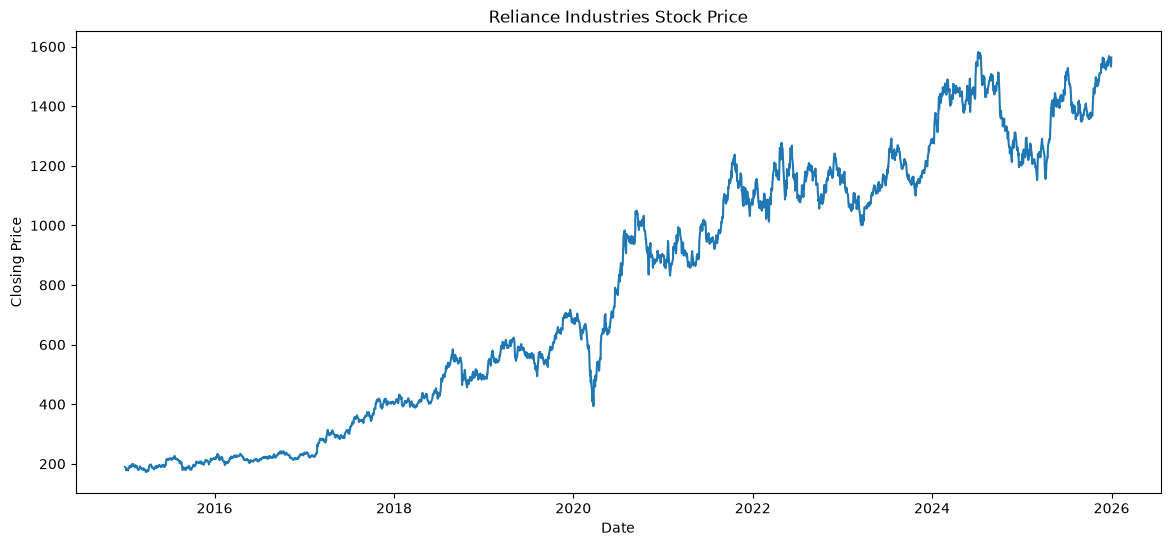

In [6]:
# Visualize the stock price

plt.figure(figsize=(14, 6))

plt.plot(data["Close"])

plt.title("Reliance Industries Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

In [7]:
## Clean & Prepare the Dataset.
# Check the data types

data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2716 entries, 2015-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   2716 non-null   float64
 1   (High, RELIANCE.NS)    2716 non-null   float64
 2   (Low, RELIANCE.NS)     2716 non-null   float64
 3   (Open, RELIANCE.NS)    2716 non-null   float64
 4   (Volume, RELIANCE.NS)  2716 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 127.3 KB


In [8]:
# Keep only the Closing Price

df = data[["Close"]].copy()

df.head()

Price,Close
Ticker,RELIANCE.NS
Date,
2015-01-01,189.125381
2015-01-02,188.624802
2015-01-05,186.558685
2015-01-06,178.091797
2015-01-07,181.968475


In [9]:
# Check missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
Price  Ticker     
Close  RELIANCE.NS    0
dtype: int64


In [10]:
# Remove missing rows

df = df.dropna()

print("Dataset shape:", df.shape)

Dataset shape: (2716, 1)


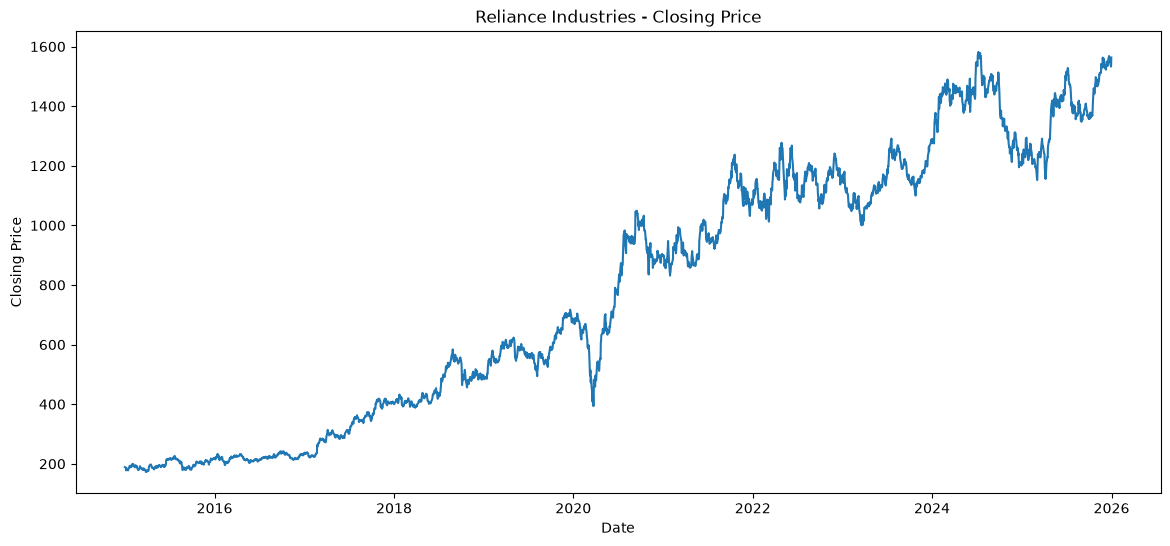

In [11]:
# Plot our cleaned data

plt.figure(figsize=(14, 6))

plt.plot(df["Close"])

plt.title("Reliance Industries - Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

In [12]:
# Look at the final dataset

df.tail()

Price,Close
Ticker,RELIANCE.NS
Date,
2025-12-24,1551.028687
2025-12-26,1552.024048
2025-12-29,1538.486694
2025-12-30,1532.713379
2025-12-31,1563.172607


In [13]:
## Split the Data into Training & Testing Sets
# Find the split point

train_size = int(len(df) * 0.8)

train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

print("Total records:", len(df))
print("Training records:", len(train_data))
print("Testing records:", len(test_data))

Total records: 2716
Training records: 2172
Testing records: 544


In [14]:
# Check the dates

print("Training period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTesting period:")
print(test_data.index.min(), "to", test_data.index.max())

Training period:
2015-01-01 00:00:00 to 2023-10-17 00:00:00

Testing period:
2023-10-18 00:00:00 to 2025-12-31 00:00:00


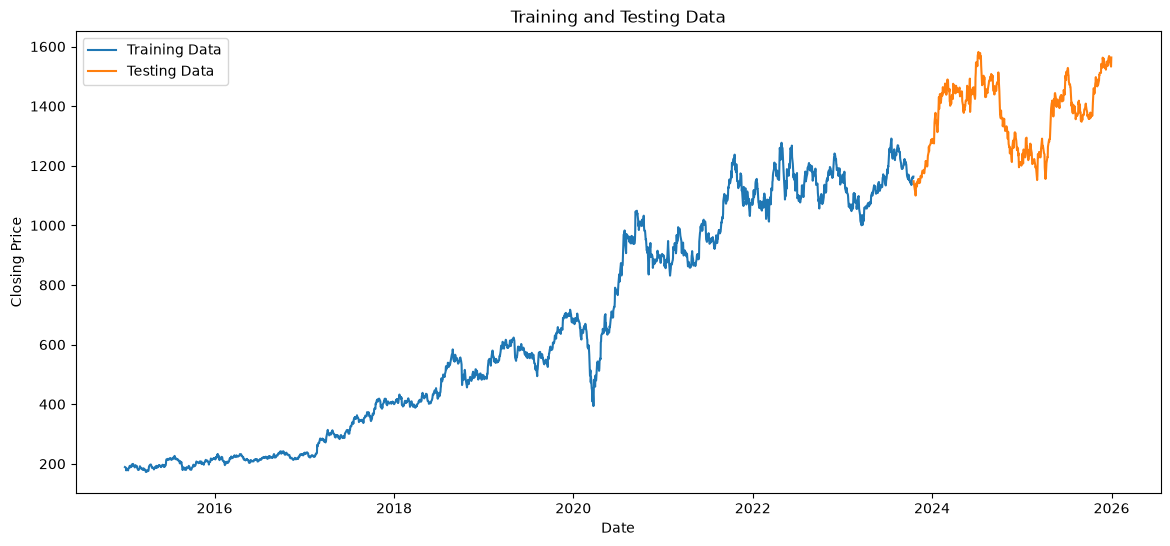

In [15]:
# Visualize the split

plt.figure(figsize=(14, 6))

plt.plot(train_data["Close"], label="Training Data")
plt.plot(test_data["Close"], label="Testing Data")

plt.title("Training and Testing Data")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

In [16]:
## Normalize the Stock Prices [Use MinMaxScaler to convert the prices to a range between 0 and 1.]
#Create the scaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

In [18]:
# 2️⃣ Fit the scaler ONLY on training data [This is important to avoid data leakage.]

train_scaled = scaler.fit_transform(train_data[["Close"]])
test_scaled = scaler.transform(test_data[["Close"]])

In [19]:
# Check the results

print("Original training prices:")
print(train_data["Close"].head())

print("\nScaled training prices:")
print(train_scaled[:5])

Original training prices:
Ticker      RELIANCE.NS
Date                   
2015-01-01   189.125381
2015-01-02   188.624802
2015-01-05   186.558685
2015-01-06   178.091797
2015-01-07   181.968475

Scaled training prices:
[[0.01469045]
 [0.01424296]
 [0.01239596]
 [0.00482699]
 [0.00829254]]


In [21]:
# Verify the range

print("Minimum:", train_scaled.min())
print("Maximum:", train_scaled.max())

Minimum: 0.0
Maximum: 1.0


In [24]:
print('''Why to doing this?

Suppose the stock prices range from:

₹400 → ₹3,000

The LSTM works more efficiently when those values are transformed into:

0 → 1

So:

₹400  → 0.00
₹1700 → ~0.50
₹3000 → 1.00''')

Why to doing this?

Suppose the stock prices range from:

₹400 → ₹3,000

The LSTM works more efficiently when those values are transformed into:

0 → 1

So:

₹400  → 0.00
₹1700 → ~0.50
₹3000 → 1.00


In [25]:
## Create 60-Day Sequences
# Create the sequences

import numpy as np

time_step = 60

X_train = []
y_train = []

for i in range(time_step, len(train_scaled)):
    X_train.append(train_scaled[i-time_step:i, 0])
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2112, 60)
y_train shape: (2112,)


In [26]:
# Create test sequences

X_test = []
y_test = []

for i in range(time_step, len(test_scaled)):
    X_test.append(test_scaled[i-time_step:i, 0])
    y_test.append(test_scaled[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (484, 60)
y_test shape: (484,)


In [28]:
# Reshape the data for LSTM
# LSTM expects data in this format: (samples, time_steps, features)

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [29]:
#Check the shape:

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2112, 60, 1)
X_test: (484, 60, 1)


In [32]:
## Build the LSTM Model
# Import the model layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

In [33]:
# Create the model

model = Sequential([
    
    Input(shape=(X_train.shape[1], 1)),
    
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    
    Dense(25),
    Dense(1)
])

In [34]:
# Compile the model

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [35]:
# Check the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train the LSTM

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0011 - val_loss: 3.9141e-04
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 9.9912e-04 - val_loss: 3.2316e-04
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 9.9871e-04 - val_loss: 3.5119e-04
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 9.8308e-04 - val_loss: 3.2624e-04
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 9.2572e-04 - val_loss: 6.7821e-04
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 9.4076e-04 - val_loss: 4.0349e-04
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 9.2863e-04 - val_loss: 4.9598e-04
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 9.7864e-04 - val_loss: 7.2918e-04
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0010 - val_loss: 5.1669e-04
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0011 - val_loss: 2.8397e-04
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 9.5280e-04 - val_loss

In [39]:
print("Model training completed!")

Model training completed!


In [40]:
## Make Predictions
# Generate predictions

predictions = model.predict(X_test)

print("Prediction shape:", predictions.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step
Prediction shape: (484, 1)


In [42]:
# Convert predictions back to actual prices

predictions = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

In [43]:
# See the first predictions

print("Predicted Prices:")
print(predictions[:10])

print("\nActual Prices:")
print(actual_prices[:10])

Predicted Prices:
[[1.4806439e+06]
 [1.4935772e+06]
 [1.4949210e+06]
 [1.4927220e+06]
 [1.4892158e+06]
 [1.4752386e+06]
 [1.4650595e+06]
 [1.4615118e+06]
 [1.4882231e+06]
 [1.5089466e+06]]

Actual Prices:
[[1358.2454834 ]
 [1345.35107422]
 [1351.65002441]
 [1351.15600586]
 [1312.7442627 ]
 [1327.86193848]
 [1336.95227051]
 [1430.79577637]
 [1390.85229492]
 [1409.62585449]]


In [44]:
# Calculate MAE

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(actual_prices, predictions)

print("MAE:", mae)

MAE: 1527776.363050981


In [45]:
# Calculate RMSE

rmse = np.sqrt(
    mean_squared_error(actual_prices, predictions)
)

print("RMSE:", rmse)

RMSE: 1531408.9085686493


In [46]:
# Calculate R²

r2 = r2_score(actual_prices, predictions)

print("R² Score:", r2)

R² Score: -226048503.95246172


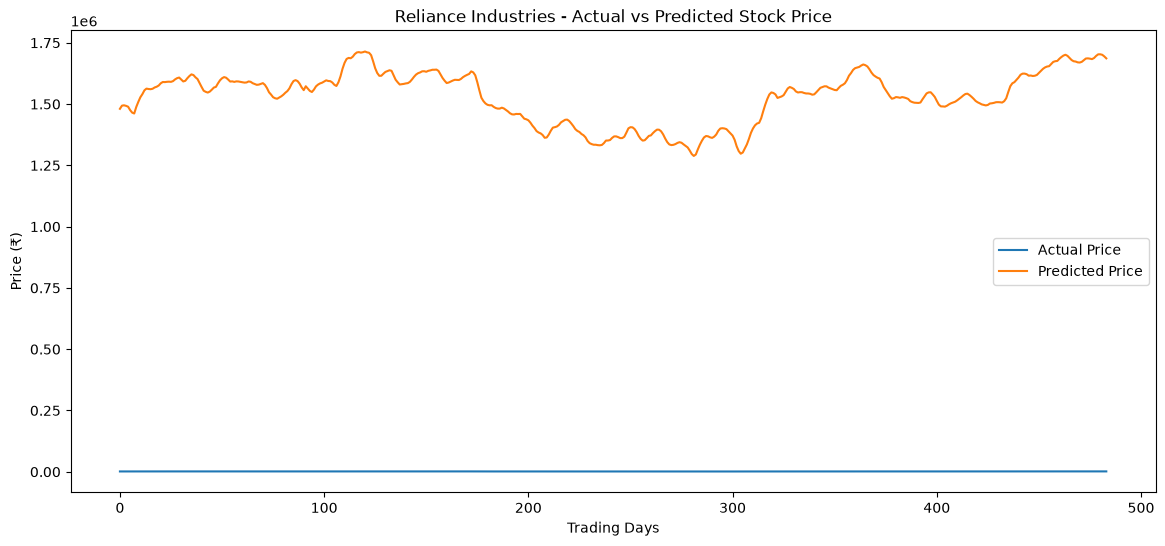

In [47]:
# Plot Actual vs Predicted

plt.figure(figsize=(14, 6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Reliance Industries - Actual vs Predicted Stock Price")
plt.xlabel("Trading Days")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()

In [54]:
## Fix the Prediction Plot
#check the actual data range 

print("Original Close price range:")
print(df["Close"].min())
print(df["Close"].max())

Original Close price range:
Ticker
RELIANCE.NS    172.692169
dtype: float64
Ticker
RELIANCE.NS    1581.824341
dtype: float64


In [49]:
print("Predictions range:")
print(predictions.min())
print(predictions.max())

print("\nActual prices range:")
print(actual_prices.min())
print(actual_prices.max())

Predictions range:
1.2883651e+06
1.7144322e+06

Actual prices range:
1151.9517822265625
1581.8243408203125


In [51]:
# Recreate the predictions correctly

# Get scaled predictions
pred_scaled = model.predict(X_test)

# Convert scaled predictions back to original price
pred_prices = scaler.inverse_transform(pred_scaled)

# Convert scaled actual values back to original price
actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Predicted price range:")
print(pred_prices.min(), pred_prices.max())

print("\nActual price range:")
print(actual_prices.min(), actual_prices.max())

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Predicted price range:
1151.5781 1532.4604

Actual price range:
1151.9517822265625 1581.8243408203125


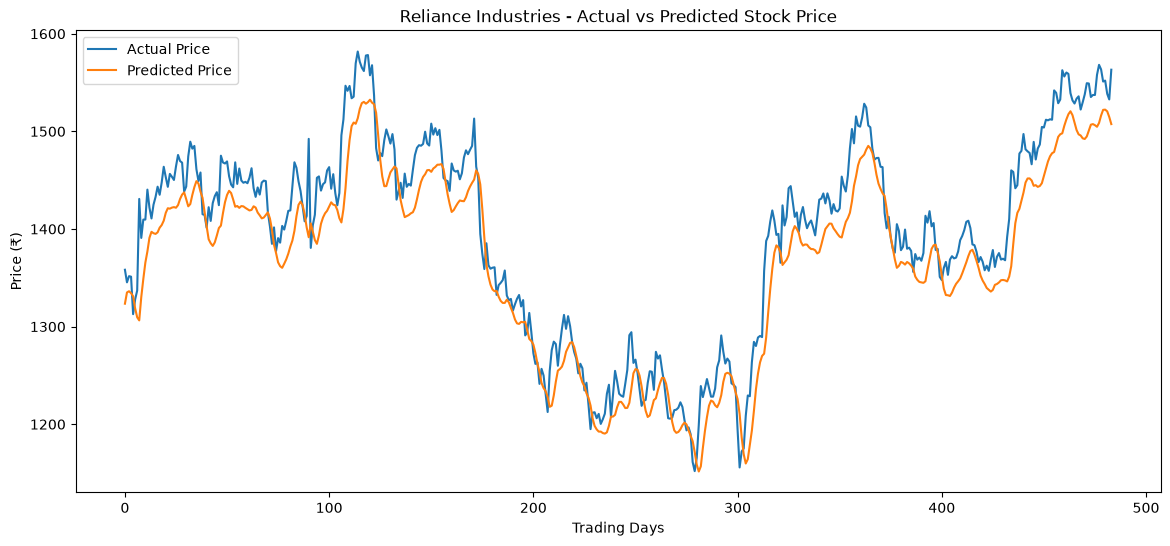

In [52]:
# plot again

plt.figure(figsize=(14, 6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(pred_prices, label="Predicted Price")

plt.title("Reliance Industries - Actual vs Predicted Stock Price")
plt.xlabel("Trading Days")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()

In [53]:
# Calculate the metrics again

mae = mean_absolute_error(actual_prices, pred_prices)

rmse = np.sqrt(
    mean_squared_error(actual_prices, pred_prices)
)

r2 = r2_score(actual_prices, pred_prices)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 30.413610032767302
RMSE: 36.34297388878796
R²  : 0.8726906722614296


In [56]:
## Save the Correct Model 
# Save the trained LSTM

model.save("stock_price_lstm.keras")

In [58]:
# Save the scaler

import joblib

joblib.dump(scaler, "stock_scaler.pkl")

['stock_scaler.pkl']

In [59]:
# Verify both files

import os

print("Model exists:", os.path.exists("stock_price_lstm.keras"))
print("Scaler exists:", os.path.exists("stock_scaler.pkl"))

Model exists: True
Scaler exists: True


In [60]:
## Train a Model for TCS
# Download TCS data

import yfinance as yf

ticker = "TCS.NS"

tcs_data = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False
)

tcs_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,,
2015-01-01,970.330139,1272.775024,1283.500000,1270.500000,1283.500000,366830
2015-01-02,983.253052,1289.724976,1295.474976,1275.300049,1275.500000,925740
2015-01-05,968.310303,1270.125000,1299.949951,1262.324951,1290.500000,1754242
2015-01-06,932.612000,1223.300049,1264.550049,1220.000000,1264.550049,2423784
2015-01-07,921.595764,1208.849976,1239.574951,1203.724976,1235.000000,2636332


In [61]:
# Extract the Close price

if isinstance(tcs_data.columns, pd.MultiIndex):
    tcs_close = tcs_data["Close"].iloc[:, 0]
else:
    tcs_close = tcs_data["Close"]

tcs_close = tcs_close.dropna()

print("TCS records:", len(tcs_close))
print("Minimum:", tcs_close.min())
print("Maximum:", tcs_close.max())

TCS records: 2716
Minimum: 1050.574951171875
Maximum: 4553.75


In [62]:
#Prepare the TCS data

tcs_df = pd.DataFrame({
    "Close": tcs_close
})

train_size = int(len(tcs_df) * 0.8)

tcs_train = tcs_df.iloc[:train_size]
tcs_test = tcs_df.iloc[train_size:]

print("Training records:", len(tcs_train))
print("Testing records:", len(tcs_test))

Training records: 2172
Testing records: 544


In [64]:
# Scale TCS prices

tcs_scaler = MinMaxScaler(feature_range=(0, 1))

tcs_train_scaled = tcs_scaler.fit_transform(
    tcs_train[["Close"]]
)

tcs_test_scaled = tcs_scaler.transform(
    tcs_test[["Close"]]
)

In [65]:
# Create 60-day sequences

time_step = 60

tcs_X_train = []
tcs_y_train = []

for i in range(time_step, len(tcs_train_scaled)):
    tcs_X_train.append(
        tcs_train_scaled[i-time_step:i, 0]
    )
    tcs_y_train.append(
        tcs_train_scaled[i, 0]
    )

tcs_X_train = np.array(tcs_X_train)
tcs_y_train = np.array(tcs_y_train)

tcs_X_test = []
tcs_y_test = []

for i in range(time_step, len(tcs_test_scaled)):
    tcs_X_test.append(
        tcs_test_scaled[i-time_step:i, 0]
    )
    tcs_y_test.append(
        tcs_test_scaled[i, 0]
    )

tcs_X_test = np.array(tcs_X_test)
tcs_y_test = np.array(tcs_y_test)

In [66]:
# Reshape the data

tcs_X_train = tcs_X_train.reshape(
    tcs_X_train.shape[0],
    tcs_X_train.shape[1],
    1
)

tcs_X_test = tcs_X_test.reshape(
    tcs_X_test.shape[0],
    tcs_X_test.shape[1],
    1
)

print("TCS X_train:", tcs_X_train.shape)
print("TCS X_test:", tcs_X_test.shape)

TCS X_train: (2112, 60, 1)
TCS X_test: (484, 60, 1)


In [67]:
# Create the TCS LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

tcs_model = Sequential([
    
    Input(shape=(60, 1)),
    
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    
    Dense(25),
    Dense(1)
])

tcs_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

tcs_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# Train the TCS model

tcs_history = tcs_model.fit(
    tcs_X_train,
    tcs_y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: 0.0146 - val_loss: 7.3431e-04
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0027 - val_loss: 6.4307e-04
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0022 - val_loss: 0.0055
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0025 - val_loss: 6.3388e-04
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0019 - val_loss: 6.1206e-04
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0019 - val_loss: 5.9098e-04
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0015 - val_loss: 5.2706e-04
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0016 - val_loss: 6.0779e-04
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0012 - val_loss: 4.9745e-04
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0013 - val_loss: 5.0282e-04
Epoch 12/20
60/60 ━━━━━━━

In [69]:
## Test TCS Prediction
# Generate TCS predictions

tcs_predictions_scaled = tcs_model.predict(
    tcs_X_test,
    verbose=0
)

print("Prediction shape:", tcs_predictions_scaled.shape)

Prediction shape: (484, 1)


In [70]:
# Convert predictions back to ₹

tcs_predictions = tcs_scaler.inverse_transform(
    tcs_predictions_scaled
)

tcs_actual_prices = tcs_scaler.inverse_transform(
    tcs_y_test.reshape(-1, 1)
)

print("Predicted price range:")
print(tcs_predictions.min(), tcs_predictions.max())

print("\nActual price range:")
print(tcs_actual_prices.min(), tcs_actual_prices.max())

Predicted price range:
2934.943 4440.6304

Actual price range:
2888.39990234375 4553.75


In [71]:
# Calculate evaluation metrics

tcs_mae = mean_absolute_error(
    tcs_actual_prices,
    tcs_predictions
)

tcs_rmse = np.sqrt(
    mean_squared_error(
        tcs_actual_prices,
        tcs_predictions
    )
)

tcs_r2 = r2_score(
    tcs_actual_prices,
    tcs_predictions
)

print("TCS MAE :", tcs_mae)
print("TCS RMSE:", tcs_rmse)
print("TCS R²  :", tcs_r2)

TCS MAE : 72.39045400067795
TCS RMSE: 94.92256362516896
TCS R²  : 0.9582840302644671


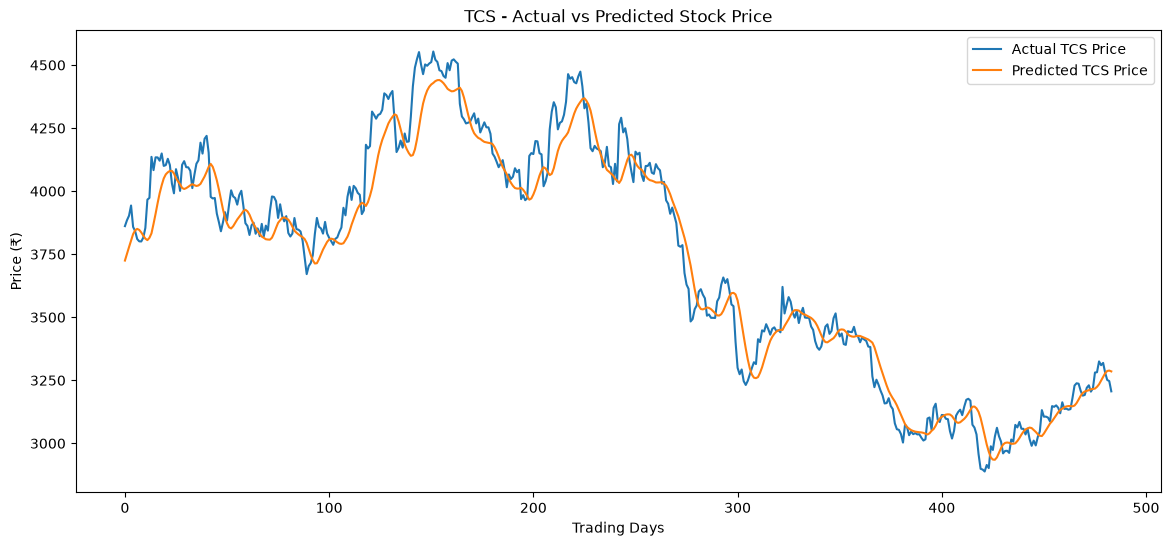

In [72]:
# Plot Actual vs Predicted

plt.figure(figsize=(14, 6))

plt.plot(
    tcs_actual_prices,
    label="Actual TCS Price"
)

plt.plot(
    tcs_predictions,
    label="Predicted TCS Price"
)

plt.title("TCS - Actual vs Predicted Stock Price")
plt.xlabel("Trading Days")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()

In [74]:
# Save the TCS model and scaler

tcs_model.save("tcs_price_lstm.keras")

joblib.dump(
    tcs_scaler,
    "tcs_scaler.pkl"
)

['tcs_scaler.pkl']

In [75]:
import os

print(
    "TCS model exists:",
    os.path.exists("tcs_price_lstm.keras")
)

print(
    "TCS scaler exists:",
    os.path.exists("tcs_scaler.pkl")
)

TCS model exists: True
TCS scaler exists: True


In [83]:
## Add More Stocks
# Train separate models first

def train_stock_model(ticker, model_name, scaler_name):

    print(f"\nTraining model for {ticker}...")

    # Download data
    stock_data = yf.download(
        ticker,
        start="2015-01-01",
        end="2026-01-01",
        auto_adjust=False
    )

    if stock_data.empty:
        print(f"No data found for {ticker}")
        return

    # Handle MultiIndex
    if isinstance(stock_data.columns, pd.MultiIndex):
        close = stock_data["Close"].iloc[:, 0]
    else:
        close = stock_data["Close"]

    close = close.dropna()

    # Create dataframe
    stock_df = pd.DataFrame({
        "Close": close
    })

    # Train/test split
    train_size = int(len(stock_df) * 0.8)

    train = stock_df.iloc[:train_size]
    test = stock_df.iloc[train_size:]

    # Scale
    stock_scaler = MinMaxScaler(
        feature_range=(0, 1)
    )

    train_scaled = stock_scaler.fit_transform(
        train[["Close"]]
    )

    test_scaled = stock_scaler.transform(
        test[["Close"]]
    )

    # Create sequences
    time_step = 60

    X_train = []
    y_train = []

    for i in range(time_step, len(train_scaled)):
        X_train.append(
            train_scaled[i-time_step:i, 0]
        )
        y_train.append(
            train_scaled[i, 0]
        )

    X_test = []
    y_test = []

    for i in range(time_step, len(test_scaled)):
        X_test.append(
            test_scaled[i-time_step:i, 0]
        )
        y_test.append(
            test_scaled[i, 0]
        )

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # Reshape
    X_train = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],
        1
    )

    X_test = X_test.reshape(
        X_test.shape[0],
        X_test.shape[1],
        1
    )

    # Create model
    stock_model = Sequential([
        Input(shape=(60, 1)),

        LSTM(50, return_sequences=True),
        Dropout(0.2),

        LSTM(50),
        Dropout(0.2),

        Dense(25),
        Dense(1)
    ])

    stock_model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )

    # Train
    stock_model.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=20,
        validation_split=0.1,
        verbose=1
    )

    # Save model
    stock_model.save(model_name)

    # Save scaler
    joblib.dump(
        stock_scaler,
        scaler_name
    )

In [84]:
print(f"{ticker} model saved successfully!")

TCS.NS model saved successfully!


In [85]:
# Train INFY

train_stock_model(
    "INFY.NS",
    "infy_price_lstm.keras",
    "infy_scaler.pkl"
)

[*********************100%***********************]  1 of 1 completed


Training model for INFY.NS...
Epoch 1/20


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0147 - val_loss: 0.0012
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0015 - val_loss: 0.0010
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0018 - val_loss: 9.7856e-04
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016 - val_loss: 8.6366e-04
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014 - val_loss: 9.0235e-04
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0015 - val_loss: 8.1164e-04
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0015 - val_loss: 9.5837e-04
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - 

In [86]:
# Train HDFCBANK

train_stock_model(
    "HDFCBANK.NS",
    "hdfcbank_price_lstm.keras",
    "hdfcbank_scaler.pkl"
)


Training model for HDFCBANK.NS...


[*********************100%***********************]  1 of 1 completed

Epoch 1/20


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0181 - val_loss: 0.0019
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0037 - val_loss: 0.0018
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0029 - val_loss: 8.3314e-04
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0022 - val_loss: 0.0014
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0022 - val_loss: 7.3150e-04
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018 - val_loss: 9.1819e-04
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.

In [87]:
# Train ICICIBANK

train_stock_model(
    "ICICIBANK.NS",
    "icicibank_price_lstm.keras",
    "icicibank_scaler.pkl"
)


Training model for ICICIBANK.NS...


[*********************100%***********************]  1 of 1 completed

Epoch 1/20


60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0140 - val_loss: 0.0028
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0021 - val_loss: 9.6765e-04
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018 - val_loss: 5.7992e-04
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016 - val_loss: 8.7562e-04
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0015 - val_loss: 5.1138e-04
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0015 - val_loss: 5.6567e-04
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014 - val_loss: 8.0605e-04
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0012 - val_loss: 8.2864e-04
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0012 - val_loss: 4.0647e-04
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0012 - val_loss: 6.9131e-04
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━

In [88]:
# Train SBIN

train_stock_model(
    "SBIN.NS",
    "sbin_price_lstm.keras",
    "sbin_scaler.pkl"
)


Training model for SBIN.NS...


[*********************100%***********************]  1 of 1 completed

Epoch 1/20


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0216 - val_loss: 0.0017
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0024 - val_loss: 0.0013
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0019 - val_loss: 0.0032
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0017 - val_loss: 9.9218e-04
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0014 - val_loss: 9.3462e-04
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0013

In [89]:
import os

files = [
    "infy_price_lstm.keras",
    "infy_scaler.pkl",
    "hdfcbank_price_lstm.keras",
    "hdfcbank_scaler.pkl",
    "icicibank_price_lstm.keras",
    "icicibank_scaler.pkl",
    "sbin_price_lstm.keras",
    "sbin_scaler.pkl"
]

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file, "NOT FOUND")

✅ infy_price_lstm.keras
✅ infy_scaler.pkl
✅ hdfcbank_price_lstm.keras
✅ hdfcbank_scaler.pkl
✅ icicibank_price_lstm.keras
✅ icicibank_scaler.pkl
✅ sbin_price_lstm.keras
✅ sbin_scaler.pkl
